In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv


In [ ]:
df = pd.read_csv('/content/diabetes_prediction_dataset.csv')

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
df.fillna(0, inplace=True)

In [ ]:
print(df.info())
print('\n')
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None




,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
df_processed = df.copy()

categorical_cols = ['gender', 'smoking_history']

df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

display(df_processed.head())

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80000, 13)
X_test shape: (20000, 13)
y_train shape: (80000,)
y_test shape: (20000,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dtc = DecisionTreeClassifier(random_state=42)

dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.95


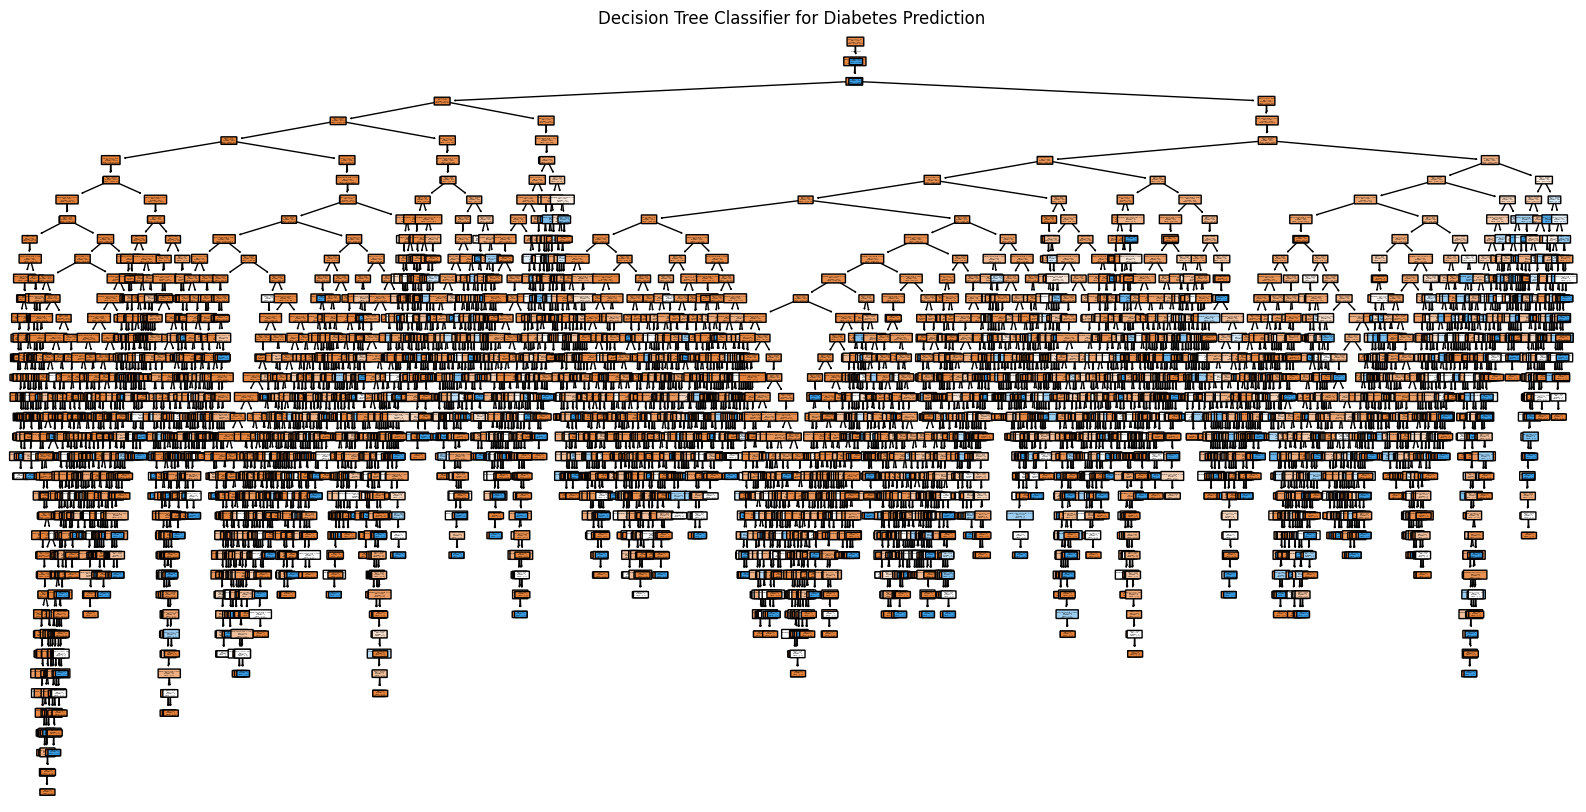

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True)
plt.title("Decision Tree Classifier for Diabetes Prediction")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dtc_id3 = DecisionTreeClassifier(criterion='entropy', random_state=42)

dtc_id3.fit(X_train, y_train)

y_pred_id3 = dtc_id3.predict(X_test)

accuracy_id3 = accuracy_score(y_test, y_pred_id3)

print(f"ID3-like Model Accuracy (Entropy): {accuracy_id3:.2f}")

ID3-like Model Accuracy (Entropy): 0.95


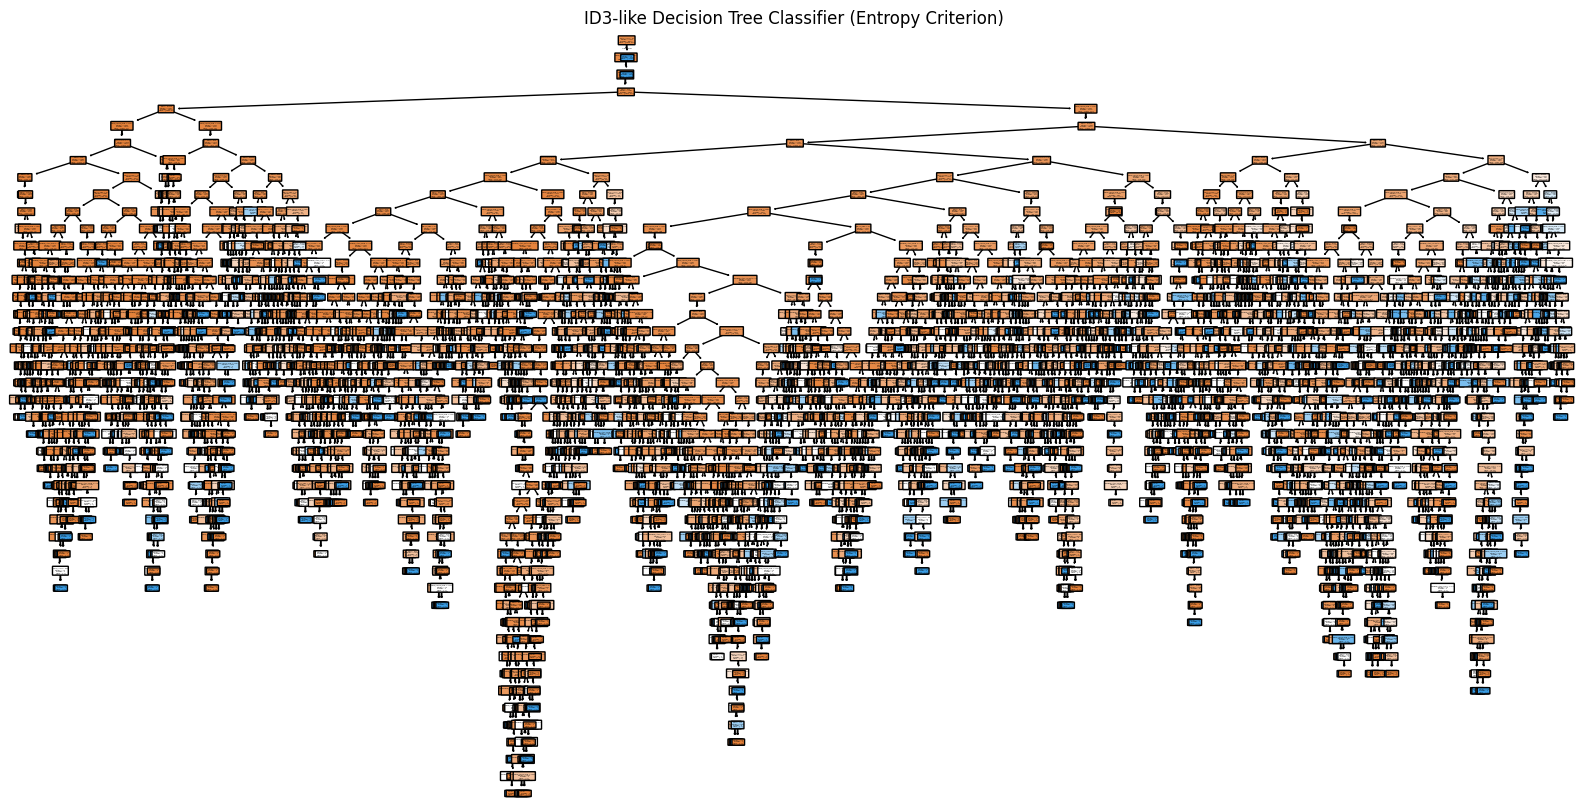

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc_id3, feature_names=X.columns, class_names=['Perished', 'Survived'], filled=True, rounded=True)
plt.title("ID3-like Decision Tree Classifier (Entropy Criterion)")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dtc_c45_like = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

dtc_c45_like.fit(X_train, y_train)

y_pred_c45_like = dtc_c45_like.predict(X_test)

accuracy_c45_like = accuracy_score(y_test, y_pred_c45_like)

print(f"C4.5-like Model Accuracy (Entropy with max_depth=5): {accuracy_c45_like:.2f}")

C4.5-like Model Accuracy (Entropy with max_depth=5): 0.97


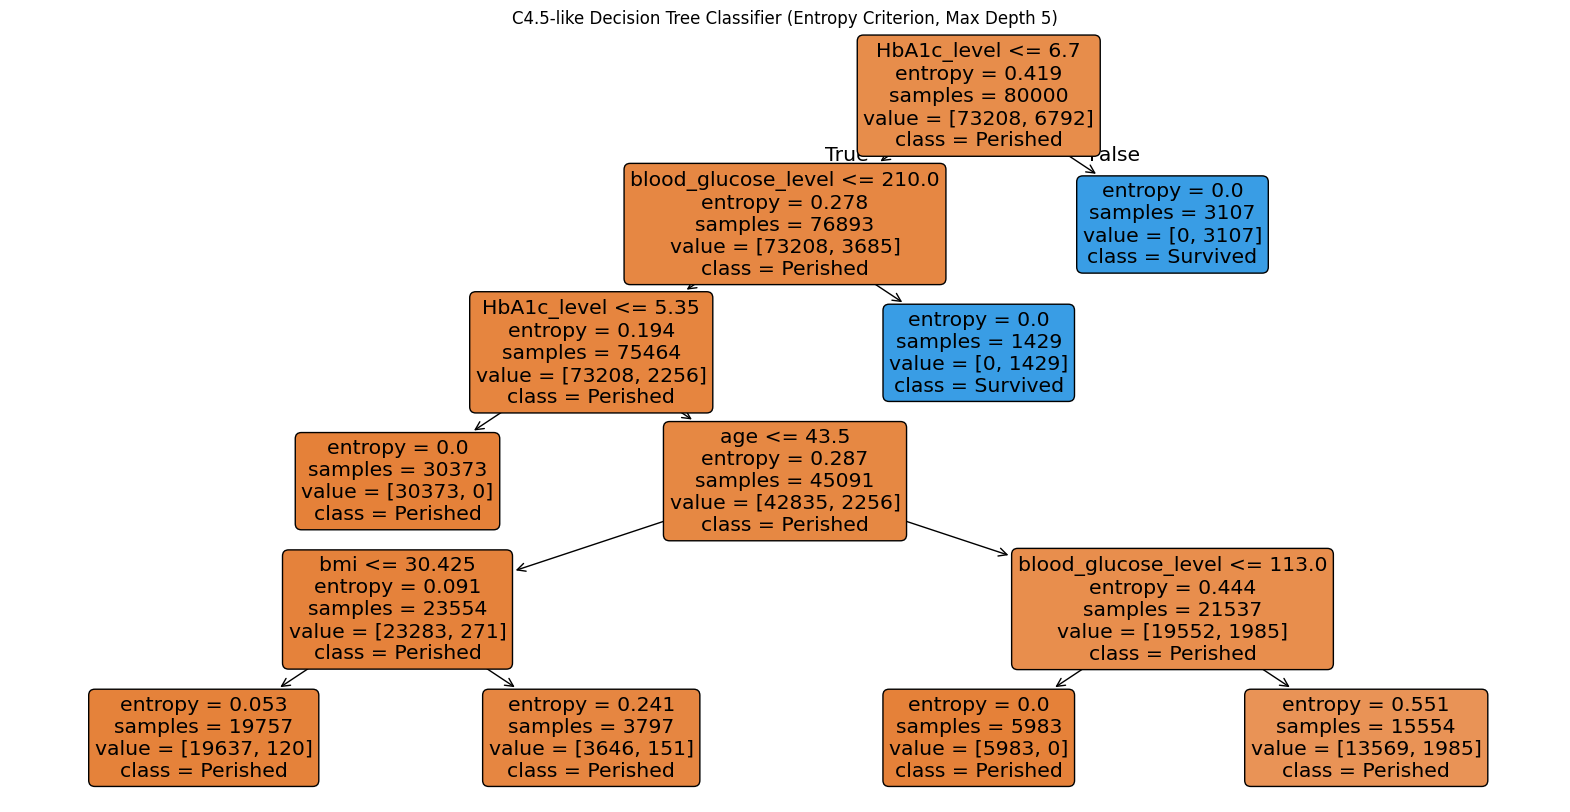

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc_c45_like, feature_names=X.columns, class_names=['Perished', 'Survived'], filled=True, rounded=True)
plt.title("C4.5-like Decision Tree Classifier (Entropy Criterion, Max Depth 5)")
plt.show()